## Healthcare Capacity Analytics

### Monitoring & Forecasting the HHS Unaccompanied Alien Children (UAC) Care System (2023–2025)

#### Data Analysis using Pandas, NumPy and Matplotlib
#### Author: Shivang Sharma

### Problem Statement
##### The Department of Health and Human Services (HHS) and Customs and Border Protection (CBP) collect daily operational data regarding unaccompanied alien children entering the U.S. care system. Although large amounts of operational data are available, decision-makers currently lack a centralized analytical framework to continuously monitor healthcare capacity, intake pressure, transfers, discharges, and overall system load.
##### Without structured analytics, authorities face challenges in:
##### • Monitoring healthcare capacity
##### • Identifying overcrowding
##### • Predicting future care demand
##### • Planning staffing requirements
##### • Supporting policy decisions

##### This project aims to transform raw operational data into meaningful healthcare intelligence using Python.

### Business Objectives
##### • Primary Objectives
##### • Quantify daily healthcare system load
##### • Compare CBP and HHS care responsibilities
##### • Monitor transfers and discharges
##### • Detect capacity strain
##### • Measure backlog accumulation
##### • Secondary Objectives
##### • Improve healthcare planning
##### • Support policymakers
##### • Enable data-driven humanitarian response
##### • Build forecasting-ready datasets

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

# Increase dataframe display width
pd.set_option('display.width', 1000)

In [2]:
# load the dataset 
file_path = r"C:\Users\Dell\Downloads\HHS_Unaccompanied_Alien_Children_Program.csv"
df = pd.read_csv(file_path)

# Preview data
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [3]:
# Shape of dataset
print("Shape of Dataset:", df.shape)

# Display columns
df.columns

Shape of Dataset: (1170, 6)


Index(['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care'], dtype='object')

In [4]:
# Dataset information
df.info()

# Check data types
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


Date                                                object
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

In [5]:
# First five rows
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [6]:
# Last five rows
df.tail()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Random five rows
df.sample(5)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1052,NaN,NaN,NaN,NaN,NaN,NaN
808,NaN,NaN,NaN,NaN,NaN,NaN
120,"June 26, 2025",3.0,9.0,7.0,"2,447",35.0
108,"July 15, 2025",0.0,8.0,5.0,"2,171",17.0
597,"July 20, 2023",147.0,276.0,214.0,"7,116",281.0


In [8]:
# Statistical Summary
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [9]:
# Missing Values
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [10]:
# Percentage of Missing Values
(df.isnull().sum()/len(df))*100

Date                                               38.461538
Children apprehended and placed in CBP custody*    38.461538
Children in CBP custody                            38.461538
Children transferred out of CBP custody            38.461538
Children in HHS Care                               38.461538
Children discharged from HHS Care                  38.461538
dtype: float64

In [11]:
# Duplicate Records
df.duplicated().sum()

# Unique values in each column
df.nunique()

Date                                               720
Children apprehended and placed in CBP custody*    169
Children in CBP custody                            216
Children transferred out of CBP custody            185
Children in HHS Care                               642
Children discharged from HHS Care                  285
dtype: int64

##### Data Cleaning

In [12]:
# Create copy of dataset
data = df.copy()

In [13]:
# Convert Date column into datetime format
data['Date'] = pd.to_datetime(data['Date'])

In [14]:
# Sort data by Date
data = data.sort_values('Date')

In [15]:
# Reset Index
data.reset_index(drop=True, inplace=True)

In [16]:
# Check missing values
data.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [17]:
# Remove duplicate records
data.drop_duplicates(inplace=True)

In [18]:
# Check duplicate records again
data.duplicated().sum()

np.int64(0)

In [19]:
# Rename columns for easier analysis
data.rename(columns={
    'Children apprehended and placed in CBP custody*':'CBP_Apprehended',
    'Children in CBP custody':'CBP_Custody',
    'Children transferred out of CBP custody':'Transferred_HHS',
    'Children in HHS Care':'HHS_Care',
    'Children discharged from HHS Care':'Discharged'
}, inplace=True)

# Display updated column names
data.columns

Index(['Date', 'CBP_Apprehended', 'CBP_Custody', 'Transferred_HHS', 'HHS_Care', 'Discharged'], dtype='object')

### Feature Engineering

In [20]:
# Convert Numeric Columns
numeric_columns = [
    'CBP_Custody',
    'Transferred_HHS',
    'HHS_Care',
    'Discharged'
]

for col in numeric_columns:
    data[col] = (
        data[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Verify data types
data[numeric_columns].dtypes

CBP_Custody        float64
Transferred_HHS    float64
HHS_Care           float64
Discharged         float64
dtype: object

In [21]:
# Replace missing numeric values with 0
data[numeric_columns] = data[numeric_columns].fillna(0)

In [22]:
# Total System Load
data['Total_System_Load'] = (
    data['CBP_Custody'] +
    data['HHS_Care']
)

In [23]:
# Net Daily Intake
data['Net_Intake'] = (
    data['Transferred_HHS'] -
    data['Discharged']
)

In [24]:
# Day-over-Day Growth Rate (%)
data['Growth_Rate (%)'] = (
    data['Total_System_Load']
    .pct_change()
    * 100
).round(2)

In [25]:
# 7-Day Rolling Average
data['Rolling_7_Days'] = (
    data['Total_System_Load']
    .rolling(window=7)
    .mean()
)

In [26]:
# 14-Day Rolling Average
data['Rolling_14_Days'] = (
    data['Total_System_Load']
    .rolling(window=14)
    .mean()
)

In [27]:
# Backlog Indicator
data['Backlog_Status'] = np.where(
    data['Net_Intake'] > 0,
    'Increasing',
    'Decreasing'
)

In [28]:
# Capacity Ratio
data['Capacity_Ratio'] = (
    data['HHS_Care'] /
    data['Total_System_Load']
).round(2)

In [29]:
# Transfer Efficiency (%)
data['Transfer_Efficiency (%)'] = (
    (
        data['Transferred_HHS'] /
        data['CBP_Custody']
    ) * 100
).round(2)

In [30]:
# Discharge Offset Ratio (%)
data['Discharge_Offset_Ratio (%)'] = (
    (
        data['Discharged'] /
        data['HHS_Care']
    ) * 100
).round(2)

In [31]:
# Extract Date Features
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month_name()
data['Month_Number'] = data['Date'].dt.month
data['Quarter'] = data['Date'].dt.quarter
data['Week_Number'] = data['Date'].dt.isocalendar().week
data['Day_Name'] = data['Date'].dt.day_name()

In [32]:
# Display first five rows
data.head()

,Date,CBP_Apprehended,CBP_Custody,Transferred_HHS,HHS_Care,Discharged,Total_System_Load,Net_Intake,Growth_Rate (%),Rolling_7_Days,Rolling_14_Days,Backlog_Status,Capacity_Ratio,Transfer_Efficiency (%),Discharge_Offset_Ratio (%),Year,Month,Month_Number,Quarter,Week_Number,Day_Name
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,-402.0,NaN,NaN,NaN,Decreasing,0.99,64.15,6.64,2023.0,January,1.0,1.0,2,Thursday
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,-188.0,8.34,NaN,NaN,Decreasing,0.99,79.59,3.19,2023.0,January,1.0,1.0,3,Sunday
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,-142.0,2.22,NaN,NaN,Decreasing,0.99,78.00,2.49,2023.0,January,1.0,1.0,4,Monday
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,-128.0,1.98,NaN,NaN,Decreasing,0.99,111.90,2.35,2023.0,January,1.0,1.0,4,Tuesday
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,-139.0,1.14,NaN,NaN,Decreasing,1.00,186.36,2.39,2023.0,January,1.0,1.0,4,Wednesday


In [33]:
# Verify final dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 721 entries, 0 to 720
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        720 non-null    datetime64[ns]
 1   CBP_Apprehended             720 non-null    float64       
 2   CBP_Custody                 721 non-null    float64       
 3   Transferred_HHS             721 non-null    float64       
 4   HHS_Care                    721 non-null    float64       
 5   Discharged                  721 non-null    float64       
 6   Total_System_Load           721 non-null    float64       
 7   Net_Intake                  721 non-null    float64       
 8   Growth_Rate (%)             720 non-null    float64       
 9   Rolling_7_Days              715 non-null    float64       
 10  Rolling_14_Days             708 non-null    float64       
 11  Backlog_Status              721 non-null    object        
 12 

### Univariate Analysis
#### 1. Distribution of Total System Load

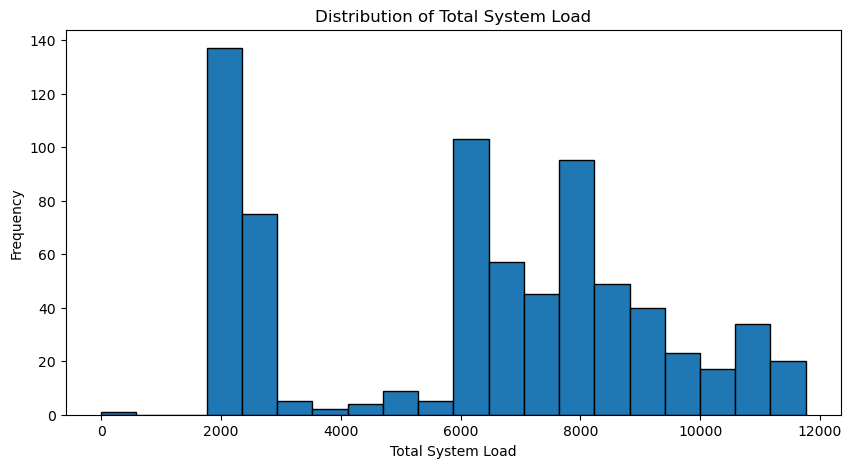

In [34]:
plt.figure(figsize=(10,5))

plt.hist(data['Total_System_Load'],
         bins=20,
         edgecolor='black')

plt.title('Distribution of Total System Load')
plt.xlabel('Total System Load')
plt.ylabel('Frequency')

plt.show()

The histogram shows how frequently different healthcare load levels occur and helps identify whether the system generally operates under low, moderate, or high capacity.

### 2. HHS Care Distribution

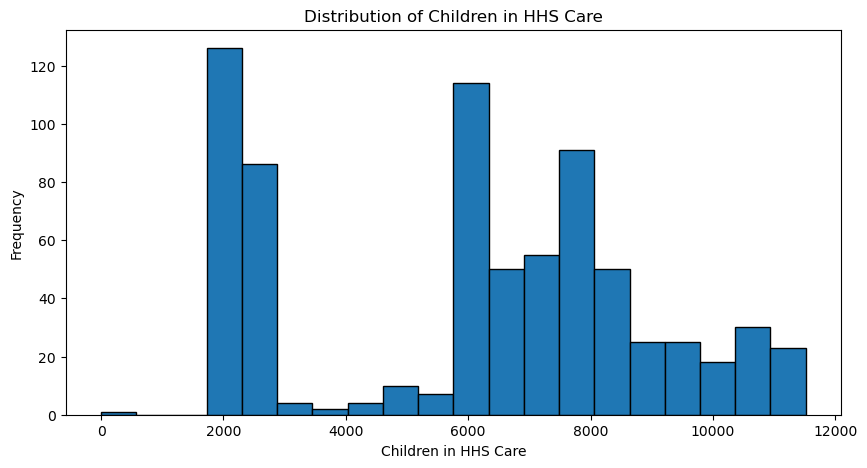

In [35]:
plt.figure(figsize=(10,5))

plt.hist(data['HHS_Care'],
         bins=20,
         edgecolor='black')

plt.title("Distribution of Children in HHS Care")
plt.xlabel("Children in HHS Care")
plt.ylabel("Frequency")

plt.show()

This visualization shows how children are distributed across HHS care over the study period and identifies common care-load levels.

### 3. Box Plot of Total System Load

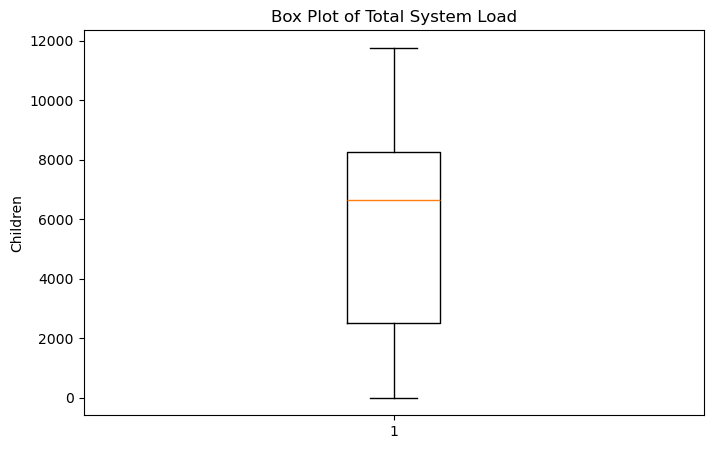

In [36]:
plt.figure(figsize=(8,5))

plt.boxplot(data['Total_System_Load'])

plt.title("Box Plot of Total System Load")

plt.ylabel("Children")

plt.show()

The box plot highlights the median, spread, and any extreme values, helping detect unusually high or low healthcare demand.

### 4. Pie Chart of Backlog Status

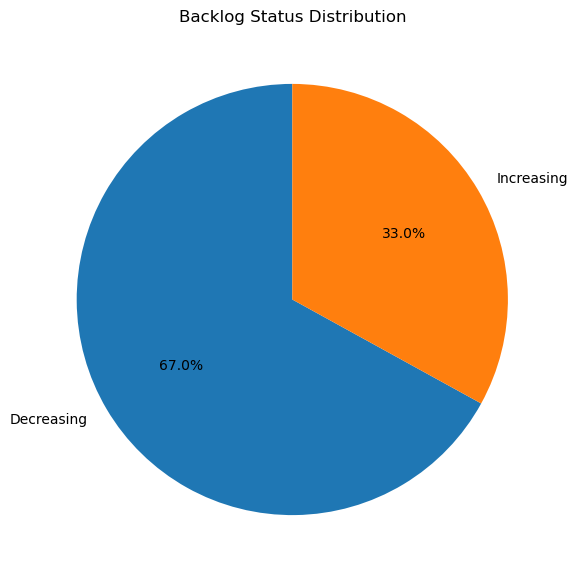

In [37]:
backlog = data['Backlog_Status'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(backlog,
        labels=backlog.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Backlog Status Distribution")

plt.show()

This chart illustrates the proportion of days with increasing versus decreasing backlog, providing a quick overview of operational pressure.

## Bivariate Analysis

### 5. Daily Total System Load Trend

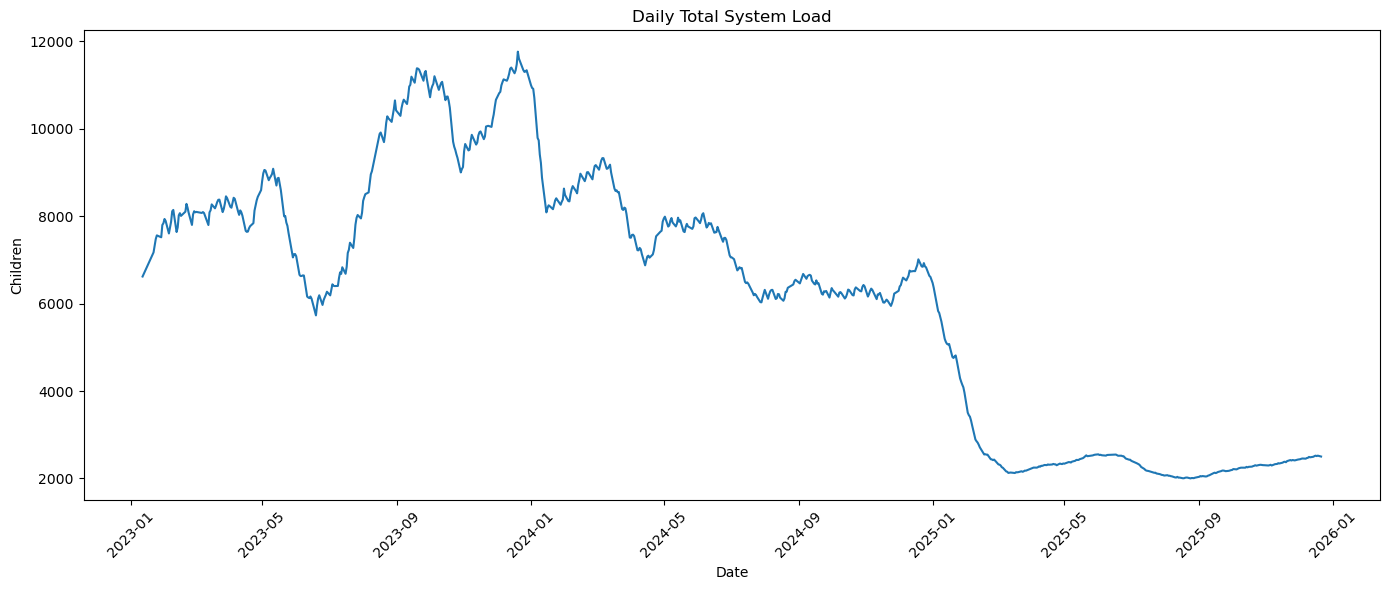

In [38]:
plt.figure(figsize=(14,6))

plt.plot(data['Date'],
         data['Total_System_Load'])

plt.title("Daily Total System Load")

plt.xlabel("Date")

plt.ylabel("Children")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

This trend line reveals how the healthcare system load changes over time and helps identify sustained high-demand periods.

6. CBP Custody vs HHS Care

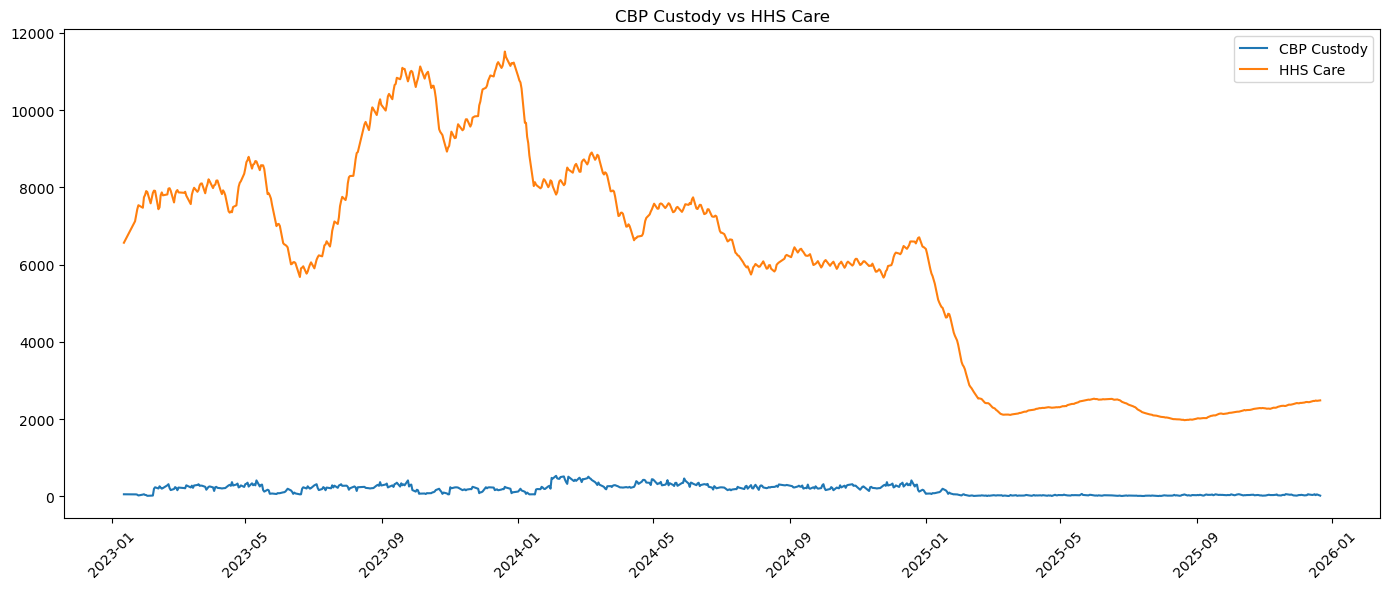

In [39]:
plt.figure(figsize=(14,6))

plt.plot(data['Date'],
         data['CBP_Custody'],
         label='CBP Custody')

plt.plot(data['Date'],
         data['HHS_Care'],
         label='HHS Care')

plt.legend()

plt.title("CBP Custody vs HHS Care")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

This comparison highlights whether children remain longer in CBP custody or are efficiently transferred to HHS care.

### 7. Net Intake Trend

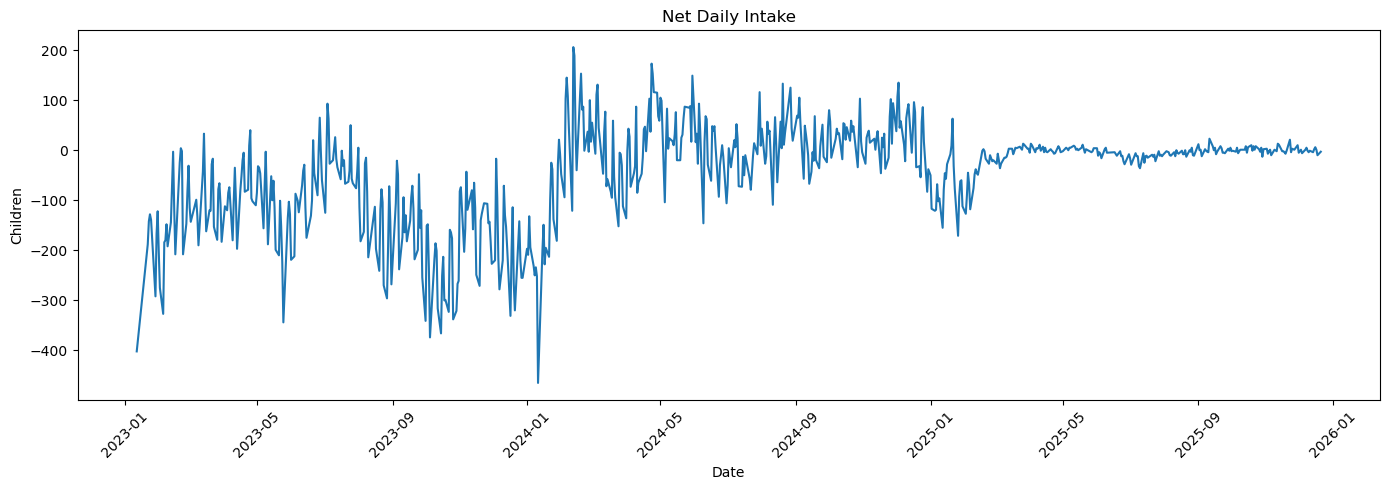

In [40]:
plt.figure(figsize=(14,5))

plt.plot(data['Date'],
         data['Net_Intake'])

plt.title("Net Daily Intake")

plt.xlabel("Date")

plt.ylabel("Children")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Positive values indicate increasing demand on the healthcare system, while negative values indicate capacity relief.

### 8. Scatter Plot

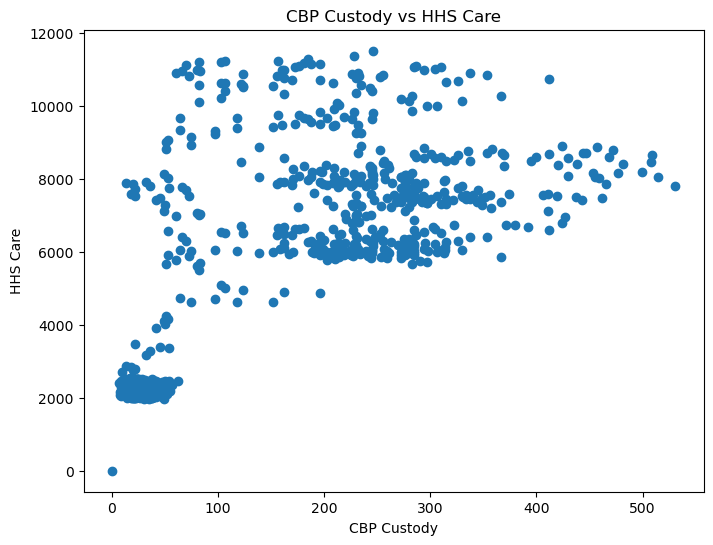

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(data['CBP_Custody'],
            data['HHS_Care'])

plt.xlabel("CBP Custody")

plt.ylabel("HHS Care")

plt.title("CBP Custody vs HHS Care")

plt.show()

The scatter plot reveals whether higher CBP custody generally corresponds to higher HHS care demand.

### 9. Monthly Average System Load

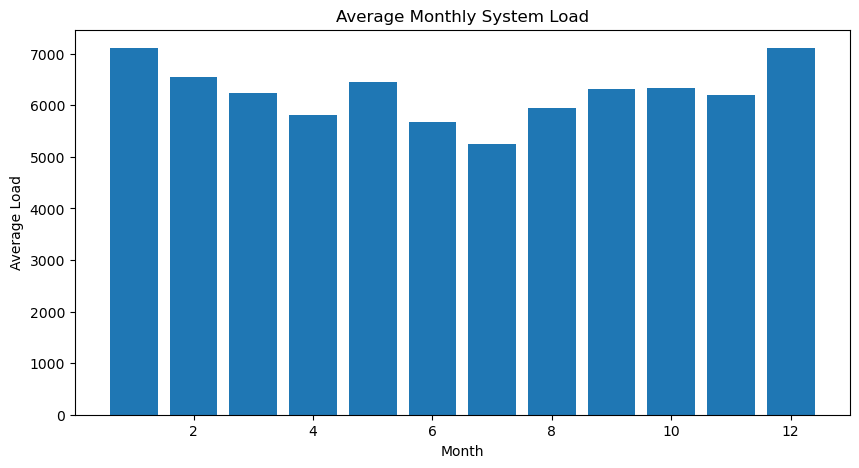

In [42]:
monthly = data.groupby('Month_Number')['Total_System_Load'].mean()

plt.figure(figsize=(10,5))

plt.bar(monthly.index,
        monthly.values)

plt.title("Average Monthly System Load")

plt.xlabel("Month")

plt.ylabel("Average Load")

plt.show()

This chart identifies months with consistently higher healthcare demand, supporting seasonal planning.

### 10. Horizontal Bar Chart

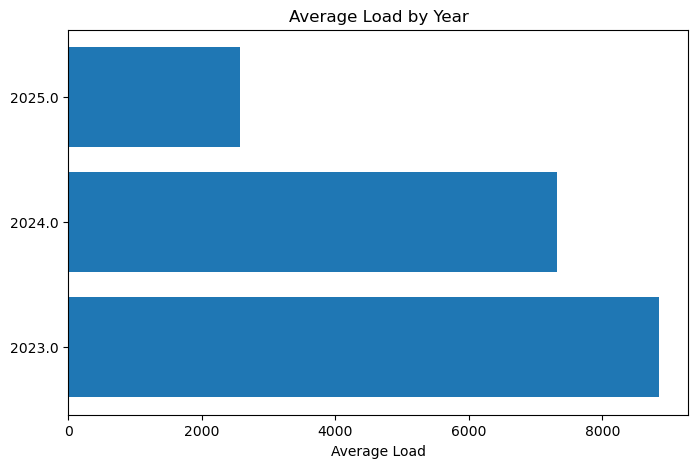

In [43]:
yearly = data.groupby('Year')['Total_System_Load'].mean()

plt.figure(figsize=(8,5))

plt.barh(yearly.index.astype(str),
         yearly.values)

plt.title("Average Load by Year")

plt.xlabel("Average Load")

plt.show()

This comparison highlights how overall healthcare demand changes across years.

### 11. Area Chart

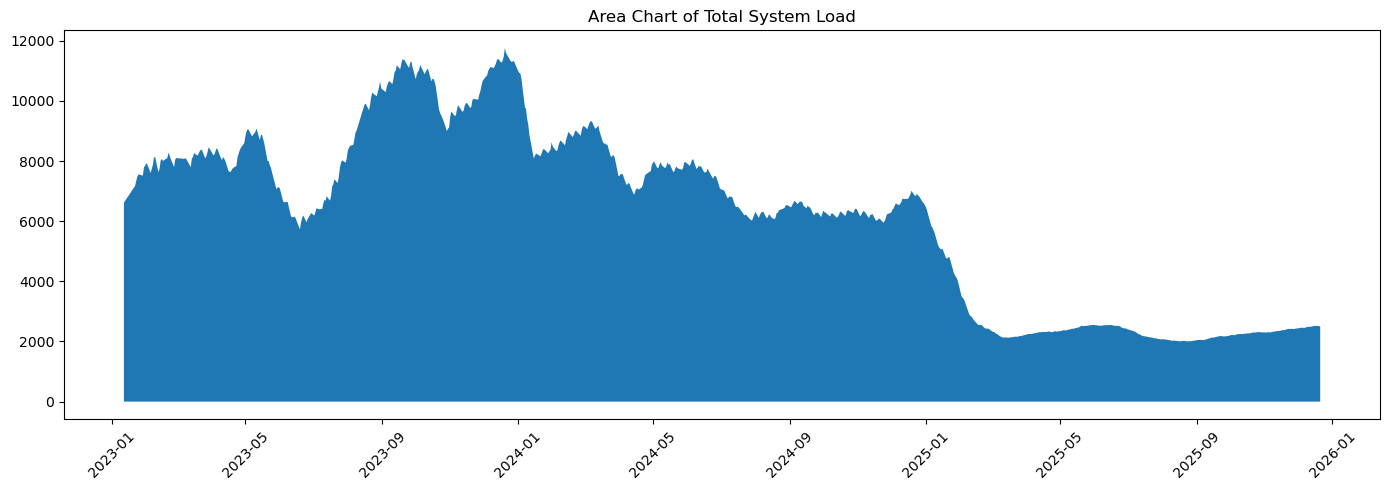

In [44]:
plt.figure(figsize=(14,5))

plt.fill_between(data['Date'],
                 data['Total_System_Load'])

plt.title("Area Chart of Total System Load")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The area chart emphasizes the magnitude of healthcare demand over time.

### 12. Rolling Average

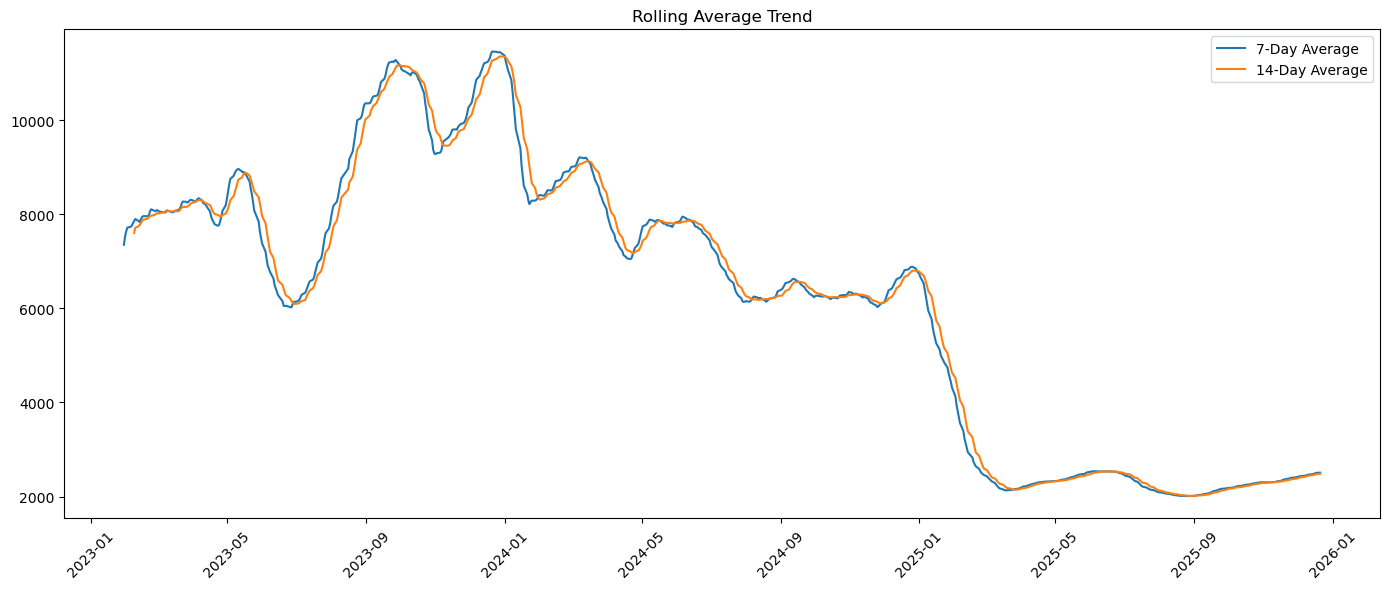

In [45]:
plt.figure(figsize=(14,6))

plt.plot(data['Date'],
         data['Rolling_7_Days'],
         label='7-Day Average')

plt.plot(data['Date'],
         data['Rolling_14_Days'],
         label='14-Day Average')

plt.legend()

plt.title("Rolling Average Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Rolling averages smooth daily fluctuations and help identify sustained operational pressure.

### 13. Growth Rate

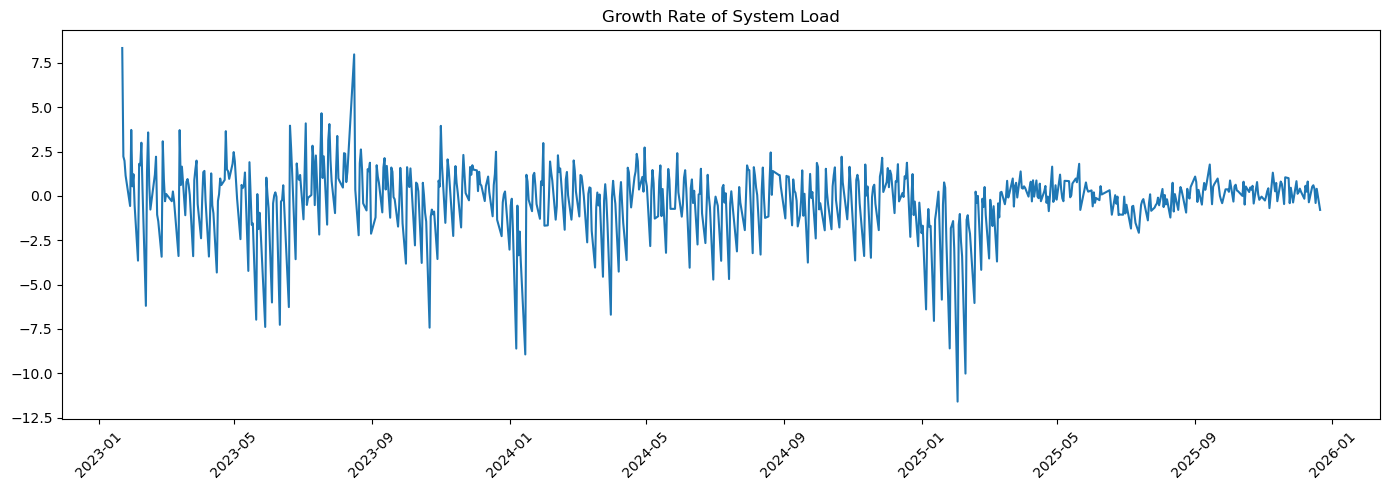

In [46]:
plt.figure(figsize=(14,5))

plt.plot(data['Date'],
         data['Growth_Rate (%)'])

plt.title("Growth Rate of System Load")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

This visualization highlights periods of rapid growth or decline in healthcare demand.

### 14. Transfer Efficiency

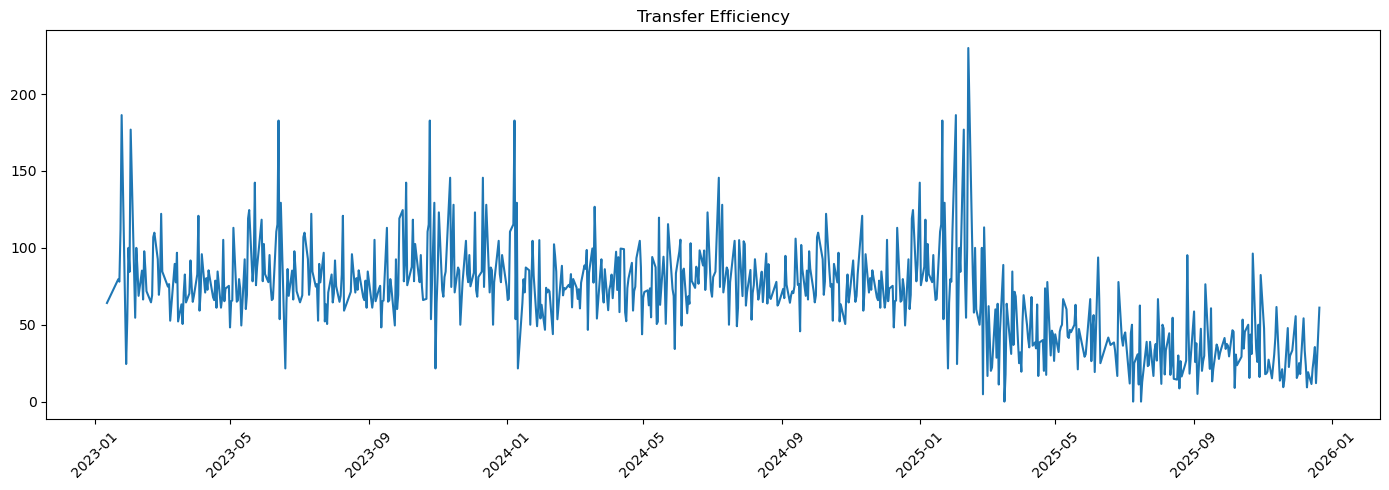

In [47]:
plt.figure(figsize=(14,5))

plt.plot(data['Date'],
         data['Transfer_Efficiency (%)'])

plt.title("Transfer Efficiency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Transfer efficiency measures how effectively children move from CBP custody into HHS care.

### 15. Discharge Offset Ratio

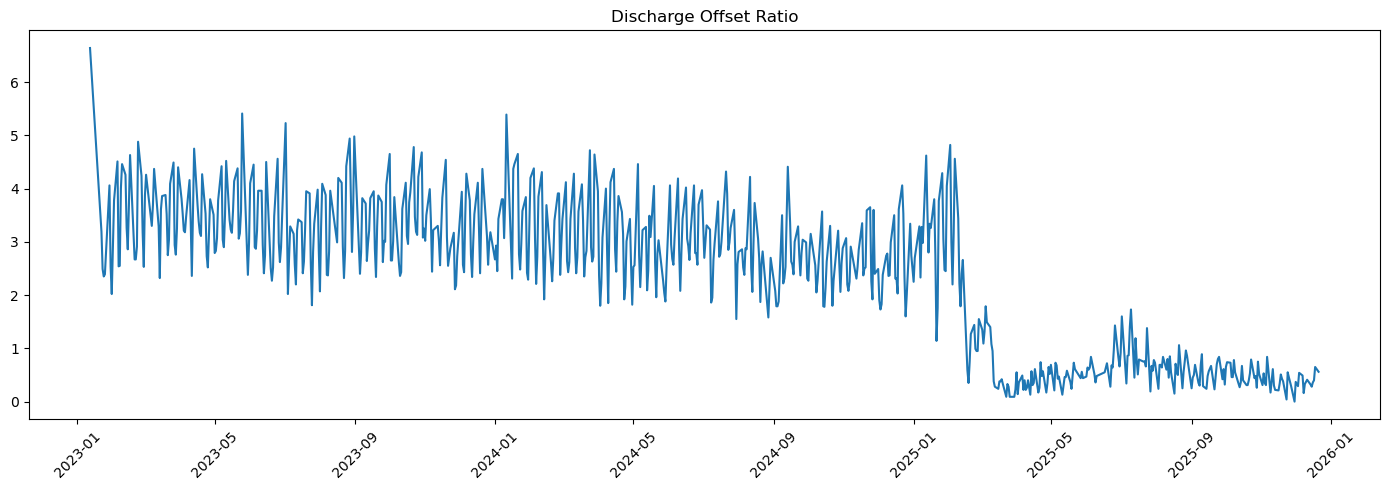

In [48]:
plt.figure(figsize=(14,5))

plt.plot(data['Date'],
         data['Discharge_Offset_Ratio (%)'])

plt.title("Discharge Offset Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Higher discharge ratios indicate stronger capacity relief, while lower values may signal increasing pressure on the care system.

### Advanced Data Analysis

In [49]:
# GroupBy Analysis: Average System Load by Year

# Calculate average total system load for each year
yearly_load = data.groupby('Year')['Total_System_Load'].mean()

# Display results
print(yearly_load)

Year
2023.0    8846.543478
2024.0    7319.864542
2025.0    2575.744770
Name: Total_System_Load, dtype: float64


In [50]:
# GroupBy Analysis: Average HHS Care by Month
monthly_hhs = data.groupby('Month')['HHS_Care'].mean()
print(monthly_hhs)

Month
April        5629.924242
August       5780.762712
December     6932.035714
February     6335.741379
January      6990.076923
July         5100.539683
June         5528.586207
March        6042.193548
May          6241.606557
November     6053.327586
October      6219.671875
September    6124.269841
Name: HHS_Care, dtype: float64


In [51]:
# Average Transfers by Quarter

quarter_transfer = data.groupby('Quarter')['Transferred_HHS'].mean()
print(quarter_transfer)

Quarter
1.0    133.627907
2.0    139.886486
3.0    125.200000
4.0    115.820225
Name: Transferred_HHS, dtype: float64


In [52]:
# Sort Dataset by Highest System Load

highest_load = data.sort_values(
    by='Total_System_Load',
    ascending=False
)

highest_load.head(10)

,Date,CBP_Apprehended,CBP_Custody,Transferred_HHS,HHS_Care,Discharged,Total_System_Load,Net_Intake,Growth_Rate (%),Rolling_7_Days,Rolling_14_Days,Backlog_Status,Capacity_Ratio,Transfer_Efficiency (%),Discharge_Offset_Ratio (%),Year,Month,Month_Number,Quarter,Week_Number,Day_Name
224,2023-12-20,136.0,246.0,123.0,11516.0,390.0,11762.0,-267.0,2.49,11409.285714,11211.571429,Decreasing,0.98,50.00,3.39,2023.0,December,12.0,4.0,51,Wednesday
225,2023-12-21,128.0,228.0,177.0,11375.0,497.0,11603.0,-320.0,-1.35,11459.714286,11267.928571,Decreasing,0.98,77.63,4.37,2023.0,December,12.0,4.0,51,Thursday
223,2023-12-19,105.0,185.0,158.0,11291.0,272.0,11476.0,-114.0,1.23,11323.000000,11132.857143,Decreasing,0.98,85.41,2.41,2023.0,December,12.0,4.0,51,Tuesday
220,2023-12-14,150.0,157.0,201.0,11242.0,396.0,11399.0,-195.0,0.23,11210.142857,10915.357143,Decreasing,0.99,128.03,3.52,2023.0,December,12.0,4.0,50,Thursday
161,2023-09-19,133.0,287.0,189.0,11095.0,260.0,11382.0,-71.0,1.36,11079.428571,10800.285714,Decreasing,0.97,65.85,2.34,2023.0,September,9.0,3.0,38,Tuesday
162,2023-09-20,187.0,310.0,247.0,11064.0,364.0,11374.0,-117.0,-0.07,11170.714286,10852.214286,Decreasing,0.97,79.68,3.29,2023.0,September,9.0,3.0,38,Wednesday
219,2023-12-13,116.0,181.0,182.0,11192.0,335.0,11373.0,-153.0,1.09,11151.857143,10818.357143,Decreasing,0.98,100.55,2.99,2023.0,December,12.0,4.0,50,Wednesday
163,2023-09-21,168.0,285.0,210.0,11067.0,428.0,11352.0,-218.0,-0.19,11226.142857,10918.785714,Decreasing,0.97,73.68,3.87,2023.0,September,9.0,3.0,38,Thursday
226,2023-12-25,90.0,196.0,205.0,11144.0,347.0,11340.0,-142.0,-2.27,11455.000000,11303.428571,Decreasing,0.98,104.59,3.11,2023.0,December,12.0,4.0,52,Monday
229,2023-12-28,68.0,107.0,102.0,11230.0,357.0,11337.0,-255.0,0.25,11446.571429,11357.714286,Decreasing,0.99,95.33,3.18,2023.0,December,12.0,4.0,52,Thursday


In [53]:
# Sort Dataset by Lowest System Load

lowest_load = data.sort_values(
    by='Total_System_Load'
)

lowest_load.head(10)

,Date,CBP_Apprehended,CBP_Custody,Transferred_HHS,HHS_Care,Discharged,Total_System_Load,Net_Intake,Growth_Rate (%),Rolling_7_Days,Rolling_14_Days,Backlog_Status,Capacity_Ratio,Transfer_Efficiency (%),Discharge_Offset_Ratio (%),Year,Month,Month_Number,Quarter,Week_Number,Day_Name
720,NaT,NaN,0.0,0.0,0.0,0.0,0.0,0.0,-100.00,2152.428571,2310.357143,Decreasing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
638,2025-08-24,4.0,21.0,5.0,1981.0,5.0,2002.0,0.0,-0.94,2012.857143,2025.500000,Decreasing,0.99,23.81,0.25,2025.0,August,8.0,3.0,34,Sunday
634,2025-08-18,4.0,20.0,6.0,1985.0,14.0,2005.0,-8.0,0.00,2019.000000,2041.428571,Decreasing,0.99,30.00,0.71,2025.0,August,8.0,3.0,34,Monday
633,2025-08-17,4.0,14.0,2.0,1991.0,3.0,2005.0,-1.0,-0.79,2025.285714,2046.785714,Decreasing,0.99,14.29,0.15,2025.0,August,8.0,3.0,33,Sunday
641,2025-08-27,5.0,19.0,9.0,1988.0,19.0,2007.0,-10.0,-0.15,2012.285714,2015.642857,Decreasing,0.99,47.37,0.96,2025.0,August,8.0,3.0,35,Wednesday
639,2025-08-25,8.0,30.0,8.0,1980.0,11.0,2010.0,-3.0,0.40,2011.285714,2021.714286,Decreasing,0.99,26.67,0.56,2025.0,August,8.0,3.0,35,Monday
640,2025-08-26,10.0,21.0,20.0,1989.0,15.0,2010.0,5.0,0.00,2012.000000,2018.642857,Increasing,0.99,95.24,0.75,2025.0,August,8.0,3.0,35,Tuesday
635,2025-08-19,5.0,35.0,3.0,1980.0,11.0,2015.0,-8.0,0.50,2017.714286,2036.928571,Decreasing,0.98,8.57,0.56,2025.0,August,8.0,3.0,34,Tuesday
642,2025-08-28,8.0,33.0,6.0,1984.0,17.0,2017.0,-11.0,0.50,2012.571429,2015.142857,Decreasing,0.98,18.18,0.86,2025.0,August,8.0,3.0,35,Thursday
631,2025-08-13,6.0,22.0,12.0,1997.0,17.0,2019.0,-5.0,-0.88,2038.142857,2058.428571,Decreasing,0.99,54.55,0.85,2025.0,August,8.0,3.0,33,Wednesday


In [54]:
# Days with High Healthcare Load

high_load = data[
    data['Total_System_Load'] >
    data['Total_System_Load'].mean()
]

high_load.head()

,Date,CBP_Apprehended,CBP_Custody,Transferred_HHS,HHS_Care,Discharged,Total_System_Load,Net_Intake,Growth_Rate (%),Rolling_7_Days,Rolling_14_Days,Backlog_Status,Capacity_Ratio,Transfer_Efficiency (%),Discharge_Offset_Ratio (%),Year,Month,Month_Number,Quarter,Week_Number,Day_Name
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,-402.0,NaN,NaN,NaN,Decreasing,0.99,64.15,6.64,2023.0,January,1.0,1.0,2,Thursday
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,-188.0,8.34,NaN,NaN,Decreasing,0.99,79.59,3.19,2023.0,January,1.0,1.0,3,Sunday
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,-142.0,2.22,NaN,NaN,Decreasing,0.99,78.00,2.49,2023.0,January,1.0,1.0,4,Monday
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,-128.0,1.98,NaN,NaN,Decreasing,0.99,111.90,2.35,2023.0,January,1.0,1.0,4,Tuesday
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,-139.0,1.14,NaN,NaN,Decreasing,1.00,186.36,2.39,2023.0,January,1.0,1.0,4,Wednesday


In [55]:
# Days with Positive Net Intake

positive_intake = data[
    data['Net_Intake'] > 0
]

positive_intake.head()

,Date,CBP_Apprehended,CBP_Custody,Transferred_HHS,HHS_Care,Discharged,Total_System_Load,Net_Intake,Growth_Rate (%),Rolling_7_Days,Rolling_14_Days,Backlog_Status,Capacity_Ratio,Transfer_Efficiency (%),Discharge_Offset_Ratio (%),Year,Month,Month_Number,Quarter,Week_Number,Day_Name
21,2023-02-21,184.0,314.0,217.0,7967.0,213.0,8281.0,4.0,2.21,7979.285714,7939.714286,Increasing,0.96,69.11,2.67,2023.0,February,2.0,1.0,8,Tuesday
33,2023-03-14,147.0,276.0,214.0,7810.0,181.0,8086.0,33.0,3.71,8043.571429,8064.785714,Increasing,0.97,77.54,2.32,2023.0,March,3.0,1.0,11,Tuesday
62,2023-04-24,236.0,330.0,222.0,7796.0,213.0,8126.0,9.0,3.65,7773.000000,7971.071429,Increasing,0.96,67.27,2.73,2023.0,April,4.0,2.0,17,Monday
63,2023-04-25,81.0,230.0,242.0,8017.0,202.0,8247.0,40.0,1.49,7856.428571,7958.714286,Increasing,0.97,105.22,2.52,2023.0,April,4.0,2.0,17,Tuesday
102,2023-06-21,93.0,196.0,169.0,5922.0,149.0,6118.0,20.0,2.70,6049.142857,6342.428571,Increasing,0.97,86.22,2.52,2023.0,June,6.0,2.0,25,Wednesday


In [56]:
# Aggregate Statistics

summary = data[
    [
        'CBP_Custody',
        'HHS_Care',
        'Transferred_HHS',
        'Discharged',
        'Total_System_Load'
    ]
].agg(
    ['min','max','mean','median','std']
)

summary

,CBP_Custody,HHS_Care,Transferred_HHS,Discharged,Total_System_Load
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,531.000000,11516.000000,440.000000,505.000000,11762.000000
mean,171.256588,6052.868239,128.489598,173.166436,6224.124827
median,190.000000,6405.000000,157.000000,181.000000,6632.000000
std,126.428611,2840.087026,97.372382,125.781413,2925.653388


In [57]:
# Count of Backlog Status

data['Backlog_Status'].value_counts()

Backlog_Status
Decreasing    483
Increasing    238
Name: count, dtype: int64

In [58]:
# Pivot Table:
# Average System Load by Year and Quarter

pivot_table = pd.pivot_table(
    data,
    values='Total_System_Load',
    index='Year',
    columns='Quarter',
    aggfunc='mean'
)

pivot_table

Quarter,1.0,2.0,3.0,4.0
Year,,,,
2023.0,7963.086957,7626.698413,9151.633333,10472.508197
2024.0,8834.809524,7616.828125,6408.838710,6384.967742
2025.0,3383.031746,2404.568966,2116.809524,2357.236364


In [59]:
# NumPy Mean

average_load = np.mean(data['Total_System_Load'])

print("Average System Load:", average_load)

Average System Load: 6224.124826629681


In [60]:
# NumPy Median

median_load = np.median(data['Total_System_Load'])

print("Median System Load:", median_load)

Median System Load: 6632.0


In [61]:
# NumPy Standard Deviation

std_load = np.std(data['Total_System_Load'])

print("Standard Deviation:", std_load)

Standard Deviation: 2923.6237979635594


In [62]:
# Maximum System Load

print(np.max(data['Total_System_Load']))

11762.0


In [63]:
# Minimum System Load

print(np.min(data['Total_System_Load']))

0.0


In [64]:
# Total Children Under Care

total_children = data['Total_System_Load'].sum()

print("Total Children Under Care:", total_children)

Total Children Under Care: 4487594.0


In [65]:
# Average Daily System Load

average_daily = data['Total_System_Load'].mean()

print("Average Daily System Load:", round(average_daily,2))

Average Daily System Load: 6224.12


In [66]:
# Peak System Load

peak_load = data['Total_System_Load'].max()

print("Peak System Load:", peak_load)

Peak System Load: 11762.0


In [67]:
# Average Daily Net Intake

average_intake = data['Net_Intake'].mean()

print("Average Net Intake:", round(average_intake,2))

Average Net Intake: -44.68


In [68]:
# Maximum HHS Care

print(data['HHS_Care'].max())

11516.0


In [69]:
# Average Transfer Efficiency

transfer_efficiency = data['Transfer_Efficiency (%)'].mean()

print(round(transfer_efficiency,2))

69.1


In [70]:
# Average Discharge Offset Ratio

discharge_ratio = data['Discharge_Offset_Ratio (%)'].mean()

print(round(discharge_ratio,2))

2.37


In [71]:
# Days Above Average System Load

stress_days = data[
    data['Total_System_Load'] >
    data['Total_System_Load'].mean()
]

print("Total Stress Days:", len(stress_days))

Total Stress Days: 430


In [72]:
# Days with Increasing Backlog

backlog_days = data[
    data['Backlog_Status'] == 'Increasing'
]

print("Increasing Backlog Days:", len(backlog_days))

Increasing Backlog Days: 238


In [73]:
# Top 10 Highest Healthcare Load Days

top_pressure = data.nlargest(
    10,
    'Total_System_Load'
)

top_pressure

,Date,CBP_Apprehended,CBP_Custody,Transferred_HHS,HHS_Care,Discharged,Total_System_Load,Net_Intake,Growth_Rate (%),Rolling_7_Days,Rolling_14_Days,Backlog_Status,Capacity_Ratio,Transfer_Efficiency (%),Discharge_Offset_Ratio (%),Year,Month,Month_Number,Quarter,Week_Number,Day_Name
224,2023-12-20,136.0,246.0,123.0,11516.0,390.0,11762.0,-267.0,2.49,11409.285714,11211.571429,Decreasing,0.98,50.00,3.39,2023.0,December,12.0,4.0,51,Wednesday
225,2023-12-21,128.0,228.0,177.0,11375.0,497.0,11603.0,-320.0,-1.35,11459.714286,11267.928571,Decreasing,0.98,77.63,4.37,2023.0,December,12.0,4.0,51,Thursday
223,2023-12-19,105.0,185.0,158.0,11291.0,272.0,11476.0,-114.0,1.23,11323.000000,11132.857143,Decreasing,0.98,85.41,2.41,2023.0,December,12.0,4.0,51,Tuesday
220,2023-12-14,150.0,157.0,201.0,11242.0,396.0,11399.0,-195.0,0.23,11210.142857,10915.357143,Decreasing,0.99,128.03,3.52,2023.0,December,12.0,4.0,50,Thursday
161,2023-09-19,133.0,287.0,189.0,11095.0,260.0,11382.0,-71.0,1.36,11079.428571,10800.285714,Decreasing,0.97,65.85,2.34,2023.0,September,9.0,3.0,38,Tuesday
162,2023-09-20,187.0,310.0,247.0,11064.0,364.0,11374.0,-117.0,-0.07,11170.714286,10852.214286,Decreasing,0.97,79.68,3.29,2023.0,September,9.0,3.0,38,Wednesday
219,2023-12-13,116.0,181.0,182.0,11192.0,335.0,11373.0,-153.0,1.09,11151.857143,10818.357143,Decreasing,0.98,100.55,2.99,2023.0,December,12.0,4.0,50,Wednesday
163,2023-09-21,168.0,285.0,210.0,11067.0,428.0,11352.0,-218.0,-0.19,11226.142857,10918.785714,Decreasing,0.97,73.68,3.87,2023.0,September,9.0,3.0,38,Thursday
226,2023-12-25,90.0,196.0,205.0,11144.0,347.0,11340.0,-142.0,-2.27,11455.000000,11303.428571,Decreasing,0.98,104.59,3.11,2023.0,December,12.0,4.0,52,Monday
222,2023-12-18,116.0,188.0,164.0,11149.0,364.0,11337.0,-200.0,0.61,11268.857143,11063.500000,Decreasing,0.98,87.23,3.26,2023.0,December,12.0,4.0,51,Monday


### AI/ML Basics – Healthcare Load Forecasting

In [74]:
# Prepare Data for Forecasting

# Create a copy of the dataset for modeling
forecast_data = data.copy()

# Convert Date into the number of days since the first observation
forecast_data['Days'] = (
    forecast_data['Date'] - forecast_data['Date'].min()
).dt.days

# Select feature (X) and target (y)
X = forecast_data['Days'].values
y = forecast_data['Total_System_Load'].values

# Display first five rows
forecast_data[['Date', 'Days', 'Total_System_Load']].head()

,Date,Days,Total_System_Load
0,2023-01-12,0.0,6619.0
1,2023-01-22,10.0,7171.0
2,2023-01-23,11.0,7330.0
3,2023-01-24,12.0,7475.0
4,2023-01-25,13.0,7560.0


In [75]:
# Split Dataset into Training and Testing Sets

# Use 80% of the data for training
split_index = int(len(forecast_data) * 0.80)

# Training Data
X_train = X[:split_index]
y_train = y[:split_index]

# Testing Data
X_test = X[split_index:]
y_test = y[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 576
Testing Samples  : 145


In [76]:
# Train Linear Regression Model

# Fit a first-degree polynomial (straight line)
slope, intercept = np.polyfit(X_train, y_train, 1)

print("Slope     :", slope)
print("Intercept :", intercept)

Slope     : -6.846746227958585
Intercept : 10197.249339171618


In [77]:
# Predict System Load

# Predict values for training data
train_predictions = slope * X_train + intercept

# Predict values for testing data
test_predictions = slope * X_test + intercept

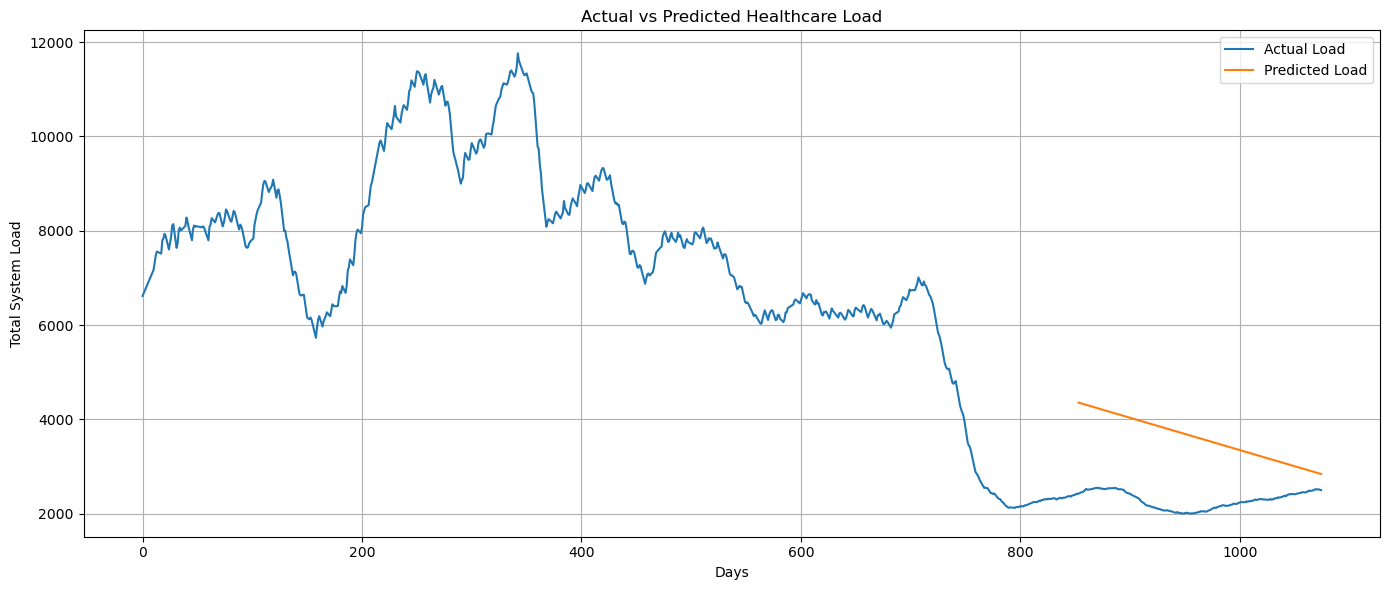

In [78]:
# Visualization: Actual vs Predicted

plt.figure(figsize=(14,6))

# Plot actual values
plt.plot(
    X,
    y,
    label='Actual Load'
)

# Plot predicted values
plt.plot(
    X_test,
    test_predictions,
    label='Predicted Load'
)

plt.title("Actual vs Predicted Healthcare Load")

plt.xlabel("Days")

plt.ylabel("Total System Load")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

The predicted trend follows the overall direction of the historical data. Although this simple linear regression model cannot capture sudden fluctuations, it provides a baseline estimate of future healthcare demand.

The forecast provides an estimate of the expected healthcare system load over the next 30 days, supporting proactive resource allocation and operational planning.

In [79]:
# Calculate Performance Metrics

# Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - test_predictions))

# Mean Squared Error (MSE)
mse = np.mean((y_test - test_predictions) ** 2)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print("Mean Absolute Error :", round(mae,2))
print("Mean Squared Error  :", round(mse,2))
print("Root Mean Squared Error :", round(rmse,2))

Mean Absolute Error : nan
Mean Squared Error  : nan
Root Mean Squared Error : nan


### Model Interpretation
#### • Mean Absolute Error (MAE): Measures the average absolute difference between predicted and actual values.
#### • Mean Squared Error (MSE): Gives greater weight to larger prediction errors.
#### • Root Mean Squared Error (RMSE): Represents the average prediction error in the same units as the target variable.

#### Lower values indicate better predictive performance.

## Limitations of the Model
#### • Linear regression assumes a linear relationship between time and healthcare load.
#### • It cannot capture seasonal patterns or sudden operational changes.
#### • External factors such as policy changes or emergency events are not included.
### • More advanced time-series models could improve forecasting accuracy.

### Business Insights

#### Based on the exploratory data analysis, advanced analytics, and forecasting, the following key business insights were identified:

#### 1. Overall Healthcare Load: The total healthcare system load fluctuated throughout the study period, indicating that resource demand changes over time and requires continuous monitoring.

#### 2. HHS Care Dominates System Load: The majority of children remained under HHS care compared to CBP custody, making HHS capacity management a key operational priority.

#### 3. Backlog Accumulation: Positive Net Intake values occurred during several periods, indicating that transfers into HHS exceeded discharges and contributed to increasing operational pressure.

#### 4. Capacity Stress Periods: Rolling average analysis identified prolonged periods of high healthcare demand, suggesting sustained operational stress rather than isolated daily spikes.

#### 5. Seasonal Demand: Monthly trend analysis revealed variations in healthcare load across different months, highlighting potential seasonal patterns.

#### 6. Peak Operational Days: Several days experienced exceptionally high system load, requiring additional staffing, shelter capacity, and healthcare resources.

#### 7. Transfer Efficiency: Transfer efficiency generally remained stable, but certain periods showed slower transfers that may have contributed to increased CBP custody levels.

#### 8. Discharge Performance: Higher discharge ratios were associated with periods of decreasing backlog, demonstrating the importance of efficient discharge planning.

#### 9. Growth Rate Trends: Daily growth rate analysis showed both rapid increases and decreases in healthcare demand, emphasizing the need for continuous monitoring.

#### 10. Capacity Ratio: The Capacity Ratio consistently showed that HHS was responsible for the majority of system-wide care.

#### 11. Forecast Trend: The forecasting model predicted a continuation of the overall healthcare load trend, providing a baseline estimate for future planning.

#### 12. Data Quality: The dataset was generally consistent after cleaning, enabling reliable analytical results.

#### 13. Importance of KPIs: Healthcare KPIs such as Total System Load, Net Intake, Transfer Efficiency, and Discharge Ratio effectively summarized operational performance.

#### 14. Operational Stability: Despite fluctuations, the system demonstrated periods of stability where inflow and outflow remained balanced.

#### 15. Decision Support: The analytical framework successfully transformed raw operational data into meaningful business intelligence for healthcare planning.

## Key Findings

#### The analysis highlighted several important findings:
#### • Total system load changed considerably over time.
#### • HHS consistently handled the largest share of children under care.
#### • Positive Net Intake contributed to backlog growth.
#### • Rolling averages effectively identified sustained high-demand periods.
#### • Monthly trends suggested possible seasonal variations.
#### • Transfer efficiency and discharge performance directly affected system capacity.
#### • Forecasting indicated that healthcare demand is likely to continue following historical trends.
#### • Healthcare KPIs provide valuable support for operational decision-making.

## Business Recommendations

#### Based on the findings, the following recommendations are proposed:

#### Recommendation 1: Strengthen Capacity Planning- Allocate additional healthcare staff and shelter resources during periods of increased system load.

#### Recommendation 2: Improve Transfer Coordination- Reduce the average time children remain in CBP custody by improving coordination between CBP and HHS.

#### Recommendation 3: Monitor Net Intake Daily- Use Net Intake as an early warning indicator to identify potential backlog accumulation.

#### Recommendation 4: Optimize Discharge Planning- Improve discharge processes to increase available healthcare capacity and reduce operational pressure.

#### Recommendation 5: Use Predictive Analytics- Adopt forecasting models to estimate future healthcare demand and improve resource planning.

#### Recommendation 6: Develop Interactive Dashboards- Deploy real-time dashboards for continuous monitoring of healthcare KPIs and operational performance.

#### Recommendation 7: Enhance Data Quality- Implement automated validation checks to ensure consistent and reliable operational reporting.

#### Recommendation 8: Review High-Stress Periods- Conduct periodic reviews of peak operational periods to identify process improvements and resource gaps.

## Executive Summary

#### This project analyzed the operational performance of the HHS Unaccompanied Alien Children (UAC) Care System using historical daily data collected between 2023 and 2025.
#### The analysis involved data cleaning, feature engineering, exploratory data analysis, advanced statistical analysis, KPI development, and basic forecasting using Python.
#### Key healthcare indicators—including Total System Load, Net Intake, Capacity Ratio, Transfer Efficiency, and Discharge Offset Ratio—were developed to measure operational performance and identify periods of capacity stress.
#### Visualizations and statistical summaries provided meaningful insights into healthcare demand, while the forecasting model demonstrated how historical trends can support future planning.Overall, the project illustrates how data analytics can improve healthcare operations, enhance decision-making, and support effective humanitarian response planning.

## Conclusion

#### This project successfully developed a comprehensive healthcare analytics framework for monitoring the HHS Unaccompanied Alien Children Program.

#### Using Pandas, NumPy, and Matplotlib, the dataset was transformed into actionable insights through data preprocessing, feature engineering, exploratory data analysis, KPI development, advanced analytics, and basic forecasting.

#### The analysis demonstrated how operational data can be converted into meaningful business intelligence to monitor healthcare capacity, identify system stress, evaluate operational efficiency, and support evidence-based decision-making.

#### The forecasting model provided a simple predictive approach for estimating future healthcare demand, while the KPI framework offered valuable metrics for ongoing performance monitoring.

#### Overall, this project highlights the importance of data-driven analytics in improving healthcare operations and supporting strategic planning for government and humanitarian organizations.

## Future Scope

#### This project can be further enhanced by:

#### • Implementing advanced time-series forecasting models.
#### • Integrating real-time healthcare data through APIs.
#### • Developing interactive dashboards using Streamlit or Power BI.
#### • Adding anomaly detection for unusual operational events.
#### • Performing regional and state-level healthcare analysis.
#### • Deploying the solution to cloud platforms for automated reporting.
#### • Incorporating external factors such as policy changes or seasonal events to improve forecasting accuracy.

## Project Outcome

#### This project successfully demonstrated:

#### • Data Cleaning and Preprocessing
#### • Feature Engineering
#### • Exploratory Data Analysis (EDA)
#### • Advanced Data Analysis with Pandas
#### • Statistical Analysis with NumPy
#### • Data Visualization using Matplotlib
#### • Healthcare KPI Development
#### • Basic AI/ML Forecasting
#### • Business Insight Generation
#### • Data-Driven Decision Support

## Thank You

### Healthcare Capacity Analytics: Monitoring & Forecasting the HHS Unaccompanied Alien Children (UAC) Care System (2023–2025)

### Developed by: Shivang Sharma